In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ipl_clean_data.csv")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24076\542382566.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ipl_clean_data.csv")


In [3]:
def match_phase(over):
    if over <= 6:
        return "powerplay"
    elif over <= 15:
        return "middle over"
    elif over <= 20:
        return "death over"
df["phase"] = df["over"].apply(match_phase)

In [4]:
df["phase"].value_counts()

phase
middle over    126942
powerplay      101712
death over      49551
Name: count, dtype: int64

In [5]:
phase_runs = df.groupby("phase")["runs_total"].sum()

In [6]:
phase_runs

phase
death over      80588
middle over    166060
powerplay      127635
Name: runs_total, dtype: int64

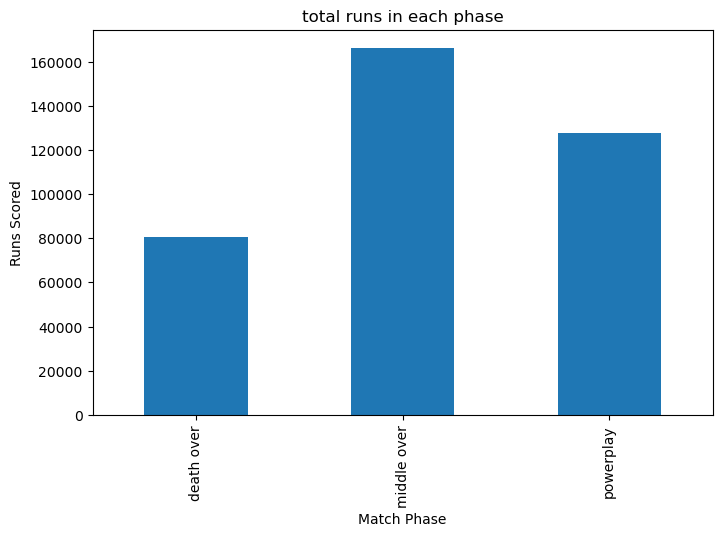

In [7]:
phase_runs.plot(kind="bar",figsize =(8,5))
plt.title("total runs in each phase")
plt.xlabel("Match Phase")
plt.ylabel("Runs Scored")
plt.show()

In [8]:
phase_balls = df.groupby("phase").size()

In [9]:
phase_balls

phase
death over      49551
middle over    126942
powerplay      101712
dtype: int64

In [10]:
phase_overs = phase_balls/6

In [11]:
phase_run_rate = phase_runs/phase_overs

In [12]:
phase_run_rate

phase
death over     9.758189
middle over    7.848939
powerplay      7.529200
dtype: float64

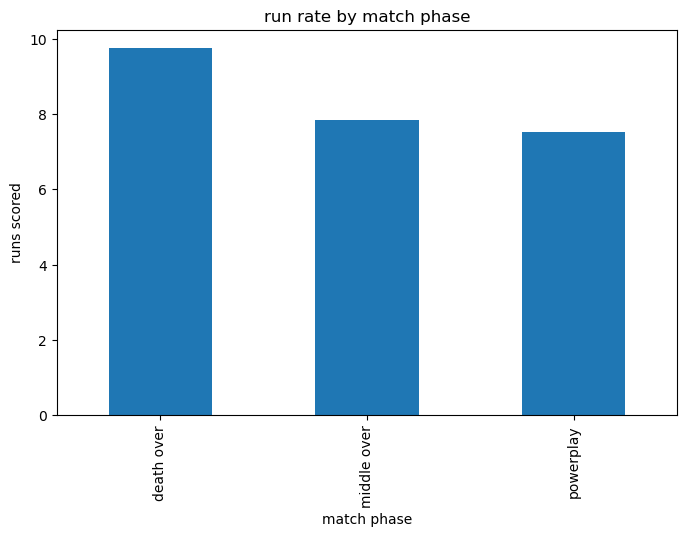

In [13]:
phase_run_rate.plot(kind="bar",figsize=(8,5))
plt.title("run rate by match phase")
plt.xlabel("match phase")
plt.ylabel("runs scored")
plt.show()

In [14]:
# 1. Pehle har match ki sirf ek row nikaalo (taki balls count na hon)
match_level_df = df.drop_duplicates(subset=['match_id'])

# 2. Ab is naye 'match_level_df' par apni insights chalao
toss_decision_counts = match_level_df['toss_decision'].value_counts()

# 3. Toss + Match win logic bhi is par chalao
match_level_df['is_toss_winner_match_winner'] = (match_level_df['toss_winner'] == match_level_df['match_won_by'])

decision_impact = match_level_df.groupby('toss_decision')['is_toss_winner_match_winner'].mean() * 100

print("--- Actual Match Statistics ---")
print(toss_decision_counts)
print(f"\nFielding Success Rate: {decision_impact['field']:.2f}%")
print(f"Batting Success Rate: {decision_impact['bat']:.2f}%")

--- Actual Match Statistics ---
toss_decision
field    764
bat      405
Name: count, dtype: int64

Fielding Success Rate: 53.40%
Batting Success Rate: 45.19%


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24076\1734644307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_level_df['is_toss_winner_match_winner'] = (match_level_df['toss_winner'] == match_level_df['match_won_by'])


In [15]:
first_innings = df[df["innings"]==1]

venue_scoring = first_innings.groupby(['match_id','venue'])["runs_total"].sum().reset_index()

venue_stats = venue_scoring.groupby("venue")["runs_total"].mean().reset_index()

venue_stats.columns = ['venue', 'avg_1st_inning_score']

top_venues = venue_stats.sort_values(by = 'avg_1st_inning_score', ascending=False)

In [28]:
# 1. Sabse pehle names ko "Standardize" karo (Comma hatao aur pehla part lo)
# Example: "MA Chidambaram Stadium, Chepauk" -> "MA Chidambaram Stadium"
df['venue_clean'] = df['venue'].str.split(',').str[0].str.strip()

# 2. Ab unique matches nikaalo is naye 'venue_clean' ke saath
match_level_df = df.drop_duplicates(subset=['match_id'])

# 3. Win Type logic apply karo (jo pehle nikaala tha)
def get_win_type(row):
    if row['match_won_by'] == row['toss_winner']:
        return 'Chase Win' if row['toss_decision'] == 'field' else 'Defend Win'
    else:
        return 'Defend Win' if row['toss_decision'] == 'field' else 'Chase Win'

match_level_df['win_type'] = match_level_df.apply(get_win_type, axis=1)

# 4. Aggregation: Stadium wise Chase aur Defend wins ko JODO (Sum)
venue_agg = match_level_df.groupby(['venue_clean', 'win_type']).size().unstack(fill_value=0)

# 5. Ab total matches aur accurate percentage nikaalo
venue_agg['Total_Matches'] = venue_agg['Chase Win'] + venue_agg['Defend Win']
venue_agg['Chase_Win_%'] = (venue_agg['Chase Win'] / venue_agg['Total_Matches']) * 100
venue_agg['Defend_Win_%'] = (venue_agg['Defend Win']/venue_agg['Total_Matches'])* 100


# 6. Sorting by Total Matches taaki meaningful data upar aaye
final_venue_data = venue_agg.reset_index().sort_values(by='Total_Matches', ascending=False).round(2)
final_venue_data = final_venue_data.reset_index()
final_venue_data.to_csv("Win_percentages_Venue.csv",index=False)

print("--- Accurate Aggregated Venue Stats ---")
final_venue_data.head(15)

--- Accurate Aggregated Venue Stats ---


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24076\2359376252.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_level_df['win_type'] = match_level_df.apply(get_win_type, axis=1)


win_type,index,venue_clean,Chase Win,Defend Win,Total_Matches,Chase_Win_%,Defend_Win_%
0,40,Wankhede Stadium,69,56,125,55.20,44.80
1,10,Eden Gardens,58,42,100,58.00,42.00
2,19,MA Chidambaram Stadium,41,50,91,45.05,54.95
3,17,M Chinnaswamy Stadium,45,39,84,53.57,46.43
4,29,Rajiv Gandhi International Stadium,47,36,83,56.63,43.37
5,32,Sawai Mansingh Stadium,41,23,64,64.06,35.94
6,11,Feroz Shah Kotla,33,27,60,55.00,45.00
7,9,Dubai International Cricket Stadium,23,23,46,50.00,50.00
8,0,Arun Jaitley Stadium,16,21,37,43.24,56.76
9,7,Dr DY Patil Sports Academy,20,17,37,54.05,45.95


In [19]:
# 1. Season column create karo
df['season'] = pd.to_datetime(df['date']).dt.year

# 2. Season-wise general stats
season_general = df.groupby('season').agg(
    total_runs=('runs_total', 'sum'),
    total_balls=('match_id', 'count'),
    total_matches=('match_id', 'nunique')
).reset_index()

# 3. Innings-wise stats (Sirf Innings 1 aur 2 lo, Super Overs hatao)
# Hum filter lagayenge: isin([1, 2])
main_innings_df = df[df['innings'].isin([1, 2])]

# Match totals calculate karo
match_innings_totals = main_innings_df.groupby(['season', 'match_id', 'innings'])['runs_total'].sum().reset_index()

# Season aur Innings ke hisaab se average nikaalo
season_innings_avg = match_innings_totals.groupby(['season', 'innings'])['runs_total'].mean().unstack().reset_index().round(2)

# Columns ko dynamically rename karo taaki mismatch na ho
season_innings_avg.columns = ['season', 'avg_1st_innings', 'avg_2nd_innings']

# 4. Merge aur Metrics calculation
season_stats = pd.merge(season_general, season_innings_avg, on='season')
season_stats['avg_runs_per_match'] = season_stats['total_runs'] / season_stats['total_matches']
season_stats['run_rate'] = (season_stats['total_runs'] / season_stats['total_balls']) * 6

# 5. Final Display
print("--- IPL Season-wise Evolution (2008-2026) ---")
final_display = season_stats[['season', 'total_matches', 'avg_runs_per_match', 'avg_1st_innings', 'avg_2nd_innings', 'run_rate']].round(2)
final_display = final_display.reset_index()
final_display.to_csv("SeasonWise_Runs_Evolution.csv",index=False)
final_display

--- IPL Season-wise Evolution (2008-2026) ---


,index,season,total_matches,avg_runs_per_match,avg_1st_innings,avg_2nd_innings,run_rate
0,0,2008,58,309.26,160.97,148.29,7.98
1,1,2009,57,286.89,150.26,136.05,7.21
2,2,2010,60,314.72,164.78,149.62,7.81
3,3,2011,73,289.78,152.37,139.32,7.46
4,4,2012,74,303.42,157.54,145.88,7.58
5,5,2013,76,297.39,155.89,140.70,7.46
6,6,2014,60,315.52,163.07,152.08,7.94
7,7,2015,59,311.07,166.25,146.95,8.07
8,8,2016,60,314.37,162.60,151.77,8.03
9,9,2017,59,318.41,165.78,152.34,8.13


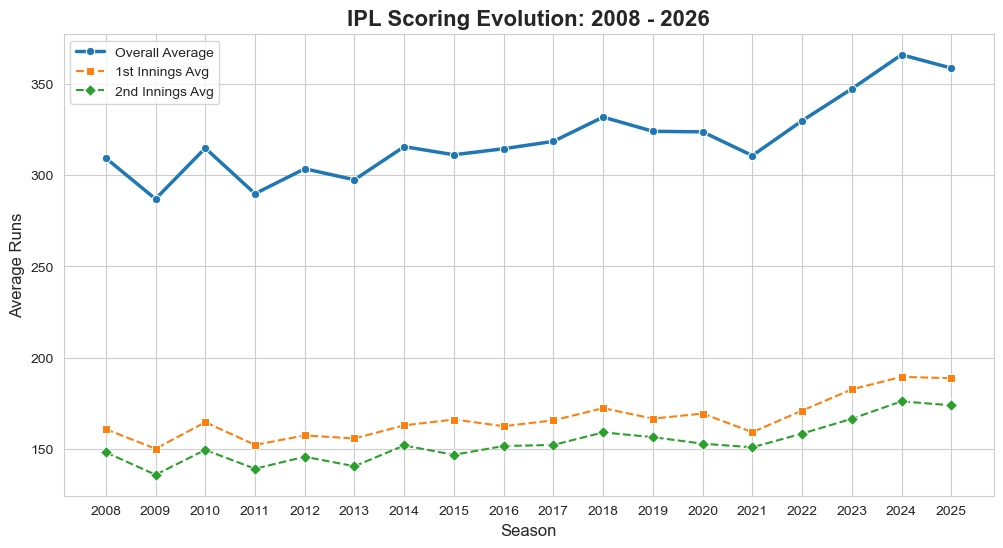

In [18]:

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 1. Plotting Overall Average
sns.lineplot(data=final_display, x='season', y='avg_runs_per_match', marker='o', label='Overall Average', linewidth=2.5)

# 2. Plotting 1st Innings Average
sns.lineplot(data=final_display, x='season', y='avg_1st_innings', marker='s', label='1st Innings Avg', linestyle='--')

# 3. Plotting 2nd Innings Average
sns.lineplot(data=final_display, x='season', y='avg_2nd_innings', marker='D', label='2nd Innings Avg', linestyle='--')

# Labels aur Title
plt.title('IPL Scoring Evolution: 2008 - 2026', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Runs', fontsize=12)
plt.xticks(final_display['season']) # Saare saal dikhane ke liye
plt.legend()

# Graph show karo
plt.show()

In [42]:
# 1. Per match runs calculate karo
venue_stats = df.groupby(['venue', 'match_id'])['runs_total'].sum().reset_index()

# 2. Venue wise average aur match count nikal lo
venue_avg = venue_stats.groupby('venue').agg({'runs_total': 'mean', 'match_id': 'count'}).reset_index().round(2)
venue_avg.columns = ['venue', 'avg_runs_per_match', 'total_matches']

# 3. Filter: Kam se kam 25 matches hue hon jo
highest_scoring_venues = venue_avg[venue_avg['total_matches'] >= 15].sort_values('avg_runs_per_match', ascending=False)

# 4. Save to CSV
highest_scoring_venues.to_csv("highest_scoring_venues.csv", index=False)

In [43]:
highest_scoring_venues.head(10)

,venue,avg_runs_per_match,total_matches
1,"Arun Jaitley Stadium, Delhi",384.13,23
15,"Eden Gardens, Kolkata",372.43,23
24,"M Chinnaswamy Stadium, Bengaluru",368.89,19
44,"Rajiv Gandhi International Stadium, Uppal, Hyd...",361.74,19
48,"Sawai Mansingh Stadium, Jaipur",358.53,17
33,"Narendra Modi Stadium, Ahmedabad",356.73,33
57,"Wankhede Stadium, Mumbai",344.50,52
6,"Brabourne Stadium, Mumbai",342.59,17
25,M.Chinnaswamy Stadium,341.80,15
4,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,333.82,22


In [48]:
# 1. Phase-wise data filter karo
pp_df = df[df['over'] < 6]
mid_df = df[(df['over'] >= 6) & (df['over'] < 15)]
death_df = df[df['over'] >= 15]

# 2. Function: Season-wise Run Rate nikalne ke liye
def get_season_rr(phase_df):
    stats = phase_df.groupby('season').agg({'runs_total': 'sum', 'ball': 'count'}).reset_index()
    stats['run_rate'] = (stats['runs_total'] / stats['ball']) * 6
    return stats.set_index('season')['run_rate']

# 3. Teeno phases ka RR calculate karo
pp_rr = get_season_rr(pp_df)
mid_rr = get_season_rr(mid_df)
death_rr = get_season_rr(death_df)

# 4. Existing evolution data (final_display) ke saath merge karo
# Note: Isme hum chase_win_percentage nahi add kar rahe hain
master_evolution = final_display.copy()

master_evolution['pp_run_rate'] = master_evolution['season'].map(pp_rr).round(2)
master_evolution['middle_run_rate'] = master_evolution['season'].map(mid_rr).round(2)
master_evolution['death_run_rate'] = master_evolution['season'].map(death_rr).round(2)

# 5. Clean up and Save
master_evolution.to_csv("IPL_Master_Scoring_Evolution.csv", index=False)

# Check the result
master_evolution

,index,season,total_matches,avg_runs_per_match,avg_1st_innings,avg_2nd_innings,run_rate,pp_run_rate,middle_run_rate,death_run_rate
0,0,2008,58,309.26,160.97,148.29,7.98,7.33,7.72,9.56
1,1,2009,57,286.89,150.26,136.05,7.21,6.88,6.67,8.76
2,2,2010,60,314.72,164.78,149.62,7.81,7.51,7.33,9.21
3,3,2011,73,289.78,152.37,139.32,7.46,6.91,7.24,8.74
4,4,2012,74,303.42,157.54,145.88,7.58,6.97,7.20,9.17
5,5,2013,76,297.39,155.89,140.70,7.46,6.73,7.07,9.22
6,6,2014,60,315.52,163.07,152.08,7.94,7.26,7.58,9.62
7,7,2015,59,311.07,166.25,146.95,8.07,7.45,7.61,9.86
8,8,2016,60,314.37,162.60,151.77,8.03,7.43,7.65,9.69
9,9,2017,59,318.41,165.78,152.34,8.13,8.04,7.67,9.22


In [51]:
df.columns

Index(['match_id', 'season', 'date', 'venue', 'city', 'innings',
       'batting_team', 'bowling_team', 'over', 'bowler_wicket', 'ball',
       'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_total',
       'runs_extras', 'valid_ball', 'wicket_kind', 'player_out', 'fielders',
       'toss_winner', 'toss_decision', 'match_won_by', 'runs_target', 'phase',
       'venue_clean'],
      dtype='object')

In [49]:
# 1. Season-wise basic bowling stats calculate karo
bowling_evolution = df.groupby('season').agg({
    'runs_total': 'sum',
    'ball': 'count',
    'bowler_wicket': 'sum',
    'extras_type': 'count' # Sirf extras wali rows count karega
}).reset_index()

# 2. Metrics calculate karo
# Economy: (Total Runs / Total Balls) * 6
bowling_evolution['avg_economy'] = (bowling_evolution['runs_total'] / bowling_evolution['ball']) * 6

# Strike Rate: (Total Balls / Total Wickets)
bowling_evolution['bowling_strike_rate'] = bowling_evolution['ball'] / bowling_evolution['bowler_wicket']

# Wickets per match nikalne ke liye unique matches se divide karna hoga
matches_per_season = df.groupby('season')['match_id'].nunique()
bowling_evolution['avg_wickets_per_match'] = bowling_evolution['bowler_wicket'] / bowling_evolution['season'].map(matches_per_season)

# 3. Dot Ball Percentage (Iske liye pehle dot balls nikalni hongi)
dot_balls = df[df['runs_batter'] == 0].groupby('season')['ball'].count()
bowling_evolution['dot_ball_percentage'] = (bowling_evolution['season'].map(dot_balls) / bowling_evolution['ball']) * 100

# 4. Round off (2 decimal tak)
bowling_evolution = bowling_evolution.round(2)

# 5. Sirf kaam ke columns rakho aur save karo
final_bowling_evolution = bowling_evolution[['season', 'avg_economy', 'bowling_strike_rate', 'avg_wickets_per_match', 'dot_ball_percentage']]
final_bowling_evolution.to_csv("IPL_Bowling_Evolution.csv", index=False)

final_bowling_evolution.head()

KeyError: "Column(s) ['extras_type'] do not exist"